# Zero Gaussian Curvature Cone Section

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import GeneralNet
from training.optimizers import GaussNewton
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh
from training.residuals import bind_model, r_data, r_eikonal, r_gauss_curvature


torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### True Surface

In [2]:
def sample_boundary(n_points=1200, dtype=torch.float64):
    third = n_points // 3
    t = torch.linspace(0, 2 * torch.pi, third, dtype=dtype)

    z1 = -torch.zeros_like(t)
    y1 = 1.0 * torch.cos(t)
    x1 = 1.0 * torch.sin(t)

    # Left loop in y-z plane (like helicoid end)
    z2 = torch.ones_like(t)
    y2 = 0.4 * torch.cos(t)
    x2 = 0.4 * torch.sin(t)

    loop1 = torch.vstack([x1, y1, z1])
    loop2 = torch.vstack([x2, y2, z2])
    return torch.cat([loop1, loop2], dim=1).T

pts_boundary = sample_boundary(n_points=1000)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

### Pretraining

In [3]:
model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
bind_model(model)
# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]


def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    x, y = pts[:, 0], pts[:, 1]
    targets = x**2 + y**2 - 1
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss= {loss.item():.6f}")

print("Pretraining completed!")

verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-3, -3, -1.5], dtype=torch.float64),
    bbox_max=torch.tensor([3, 3, 1.5], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()


Pretrain Iter 0: Loss= 0.091712
Pretrain Iter 100: Loss= 0.047754
Pretrain Iter 200: Loss= 0.002024
Pretrain Iter 300: Loss= 0.000846
Pretrain Iter 400: Loss= 0.000410
Pretrain Iter 500: Loss= 0.000210
Pretrain Iter 600: Loss= 0.000118
Pretrain Iter 700: Loss= 0.000073
Pretrain Iter 800: Loss= 0.000058
Pretrain Iter 900: Loss= 0.000039
Pretraining completed!


/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

### Main training loop

In [4]:
pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
#pts_eikonal = torch.cat((pts_eikonal, pts_boundary))
pts_surface = pts_boundary

# Gauss-Newton weights:
# loss_weights = {"interface": 1.0, "eikonal": 0.001, "gauss_curvature": 1.0}
# Adam weights:
loss_weights = {"data": 1.0, "eikonal": 0.1, "gauss_curvature": 1.0}

vals_gauss_curvature = torch.zeros(pts_surface.shape[0], dtype=torch.float64)
# vals_gauss_curvature = dome_curvature(pts_surface)

config = {
    "pts_data": pts_boundary,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "vals_gauss_curvature": vals_gauss_curvature,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

model = model.double()

  0%|          | 0/1000 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


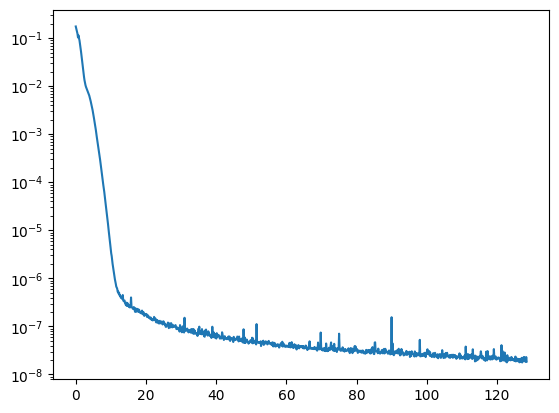

In [5]:
model = model.double()
params = model.params
loss_over_time = {}
best_loss = float('inf')
start_time = time.time()
current_time = 0
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-1, config=config)
# Adam:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in (pbar:=trange(1000)):
    if current_time > 300:
        break
    optimizer.zero_grad()
    loss_data  = 0.5*r_data(params, pts_boundary, torch.zeros(pts_boundary.shape[0], dtype=torch.float64)).squeeze(1).square().mean()

    loss_eikonal  = 0.5*r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    pts_surface = sample_model_surface_binsearch(model, pts_boundary, bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_surface)
    vals_gauss_curvature = torch.zeros(pts_surface.shape[0], dtype=torch.float64)
    config["pts_surface"] = pts_surface
    config["vals_gauss_curvature"] = vals_gauss_curvature
    optim.config = config
    
    loss_gauss_curvature = 0.5*r_gauss_curvature(params, pts_surface, vals_gauss_curvature).squeeze(1).square().mean()
       
    loss = loss_weights["data"] * loss_data + loss_weights["eikonal"] * loss_eikonal + loss_weights["gauss_curvature"] * loss_gauss_curvature
    loss.backward()
    with torch.no_grad():
        loss_metric = loss_data + loss_gauss_curvature
        loss_over_time[current_time] = loss_metric.item()
        pbar.set_description(f"interface: {loss_data.item():.2e} "
                                f"eikonal: {loss_eikonal.item():.2e} "
                                f"gauss curvature: {loss_gauss_curvature.item():.2e} "
                                f"{len(pts_surface)}"
                                )
    optimizer.step()
    current_time = time.time() - start_time

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

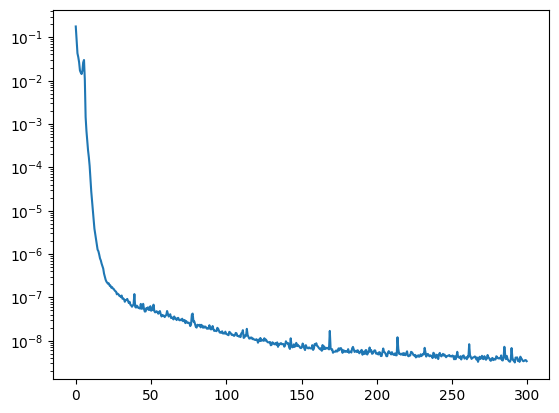

In [7]:
plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


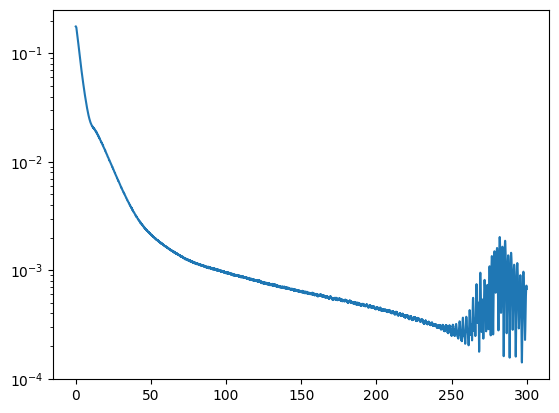

In [5]:
model = model.double()
params = model.params
loss_over_time = {}
best_loss = float('inf')
start_time = time.time()
current_time = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=18000)

for i in (pbar := trange(10000)):
    if current_time > 300:
        break
    optimizer.zero_grad()
    
    # Sample points on the surface (no torch.no_grad here since we need gradients!)
    pts_surface = sample_model_surface_binsearch(model, pts_boundary, bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_surface)
    
    vals_gauss_curvature = torch.zeros(pts_surface.shape[0], dtype=torch.float64)
    # Compute losses
    loss_interface = 0.5 * model.f(params, pts_boundary).square().mean()
    loss_eikonal = 0.5 * model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
    loss_gauss_curvature = 0.5 * model.r_gauss_curvature(params, pts_surface, vals_gauss_curvature).squeeze(1).square().mean()

    loss = (
        loss_weights["interface"] * loss_interface +
        loss_weights["eikonal"] * loss_eikonal +
        loss_weights["gauss_curvature"] * loss_gauss_curvature
    )

    # Backward and update
    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_gauss_curvature
        loss_over_time[current_time] = loss_metric.item()
        # Logging
        pbar.set_description(
            f"interface: {loss_interface.item():.2e} "
            f"eikonal: {loss_eikonal.item():.2e} "
            f"gauss curvature: {loss_gauss_curvature.item():.2e} "
            f"{len(pts_surface)}"
        )
        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())
    optimizer.step()
    current_time = time.time() - start_time

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

In [13]:
model.load_state_dict(torch.load('3,32,32,1,tanh,cone,gn'))

<All keys matched successfully>

In [6]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.2, -1.2, -0.3], dtype=torch.float64),
    bbox_max=torch.tensor([1.2, 1.2, 1.2], dtype=torch.float64),
    chunks=2
)


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.02)
fig.display()

Output()

In [8]:
torch.save(model.state_dict(), '3,32,32,1,tanh,cone,adam')

In [9]:
os.makedirs("Data Cone", exist_ok=True)

loss_file = os.path.join("Data Cone", "loss_over_time_cone_adam.pth")

torch.save(loss_over_time, loss_file)
print(f"Loss saved to {loss_file}")

Loss saved to Data Cone/loss_over_time_cone_adam.pth


In [41]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1.2, -1.2, -0.3], dtype=torch.float64),
    bbox_max=torch.tensor([1.2, 1.2, 1.2], dtype=torch.float64),
    chunks=2
)


fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.01)
fig.display()

Output()

### Visualize the result

In [103]:
verts, faces = get_mesh(
    model.float(), N=256, device=device,
    bbox_min=torch.tensor([-2, -2, -1.25], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 1.25], dtype=torch.float64),
    chunks=2
)

model.double()
mean_curvatures = model.r_mean_curvature(params, torch.tensor(verts, dtype=torch.float64)).squeeze(1).abs()

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)

color_map = k3d.basic_color_maps.Jet
color_range = [0, 0.005]

fig += k3d.mesh(
    verts, faces, 
    attribute=mean_curvatures.cpu().detach().numpy().astype(np.float32),
    color_range=color_range,
    color_map=color_map,
    side='double',
    flat_shading=False
)

fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

In [8]:
pts_surface = sample_model_surface_binsearch(model, pts_boundary, bound_limit=1)
pts_surface = sample_model_surface_newton(model, pts_surface)

In [6]:
# import time
# import torch
# from tqdm import trange
# import matplotlib.pyplot as plt

pts_surface = sample_model_surface_binsearch(model, pts_boundary, bound_limit=1)
pts_surface = sample_model_surface_newton(model, pts_surface)
params = model.params
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
loss_cache = {}
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)

# LBFGS Optimizer
# optim = torch.optim.LBFGS(model.parameters(), lr=1e-3, max_iter=20, tolerance_grad=1e-7, tolerance_change=1e-9)
optim = torch.optim.LBFGS(model.parameters())


start_time = time.time()
current_time = 0
for i in (pbar:=trange(10000)):
    if current_time > 300:
        break 
    
    def closure():
        optim.zero_grad()
        
        loss_interface  = 0.5 * model.f(params, pts_boundary).square().mean()

        loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
        try:
            pts_surface = sample_model_surface_binsearch(model, pts_boundary, bound_limit=1)
            pts_surface = sample_model_surface_newton(model, pts_surface)
        except:
            pass
        config["pts_surface"] = pts_surface
        optim.config = config
        
        ## 3) Curvature loss
        vals_gauss_curvature = torch.zeros(pts_surface.shape[0], dtype=torch.float64)
        loss_curvature = 0.5 * model.r_gauss_curvature(params, pts_surface, vals_gauss_curvature).squeeze(1).square().mean()
        
        loss = (
            loss_weights["interface"] * loss_interface +
            loss_weights["eikonal"] * loss_eikonal +
            loss_weights["gauss_curvature"] * loss_curvature
        )

        loss_cache["interface"] = loss_interface.item()
        loss_cache["eikonal"] = loss_eikonal.item()
        loss_cache["curvature"] = loss_curvature.item()
        loss_cache["total"] = loss.item()
        loss_cache["pts_surface"] = pts_surface
        
        loss.backward()
        return loss
    
    loss = optim.step(closure)
    
    with torch.no_grad():
        loss_metric = loss_cache["interface"] + loss_cache["curvature"]
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric
        pbar.set_description(f"interface: {loss_cache['interface']:.2e} "
                             f"eikonal: {loss_cache['eikonal']:.2e} "
                             f"curvature: {loss_cache['curvature']:.2e} "
                             f"{len(loss_cache['pts_surface'])}"
                            )

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()


  0%|          | 0/10000 [00:00<?, ?it/s]

IndexError: select(): index 0 out of range for tensor of size [0] at dimension 0

### LBFGS